# Bài Tập Qua Tết 
## Thử trên tập data MNIST và cat and dog
    - deadline 6/03/2026
    - Nhưng phải làm theo cấu trúc file lab
    - Dùng PyTorh

# Tập data MNIST 

In [78]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [79]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=True)
train_loader = DataLoader(dataset=train_dataset, batch_size=1000, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=1000, shuffle=False)
images, labels = next(iter(train_loader))
images_test, labels_test = next(iter(test_loader))

print(f"Số lượng ảnh train: {len(train_dataset)}")
print(f"Số lượng ảnh test: {len(test_dataset)}")

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:03<00:00, 2.98MB/s]


Extracting ./data\MNIST\raw\train-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 92.8kB/s]


Extracting ./data\MNIST\raw\train-labels-idx1-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:01<00:00, 950kB/s] 


Extracting ./data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 4.52MB/s]


Extracting ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\MNIST\raw

Số lượng ảnh train: 60000
Số lượng ảnh test: 10000


In [ ]:
# Xây ANN bằng PyTorch
class ANN_MNIST(nn.Module):
    def __init__(self):
        super(ANN_MNIST, self).__init__()
        self.layer1 = nn.Linear(784, 128)  # Đầu vào 784, ẩn 128
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(128, 10)   # Đầu ra 10 lớp (0-9)

    def forward(self, x):
        x = x.view(-1, 784) # Duỗi ảnh 2D thành 1D
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x

# Khởi tạo mô hình
model = ANN_MNIST()
# Định nghĩa mất mát và tối ưu hóa
criterion = nn.CrossEntropyLoss() 
optimizer = optim.Adam(model.parameters(), lr=0.01)
# Huấn luyện
loss_history = []
acc_history = []
epochs = 50
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    
    # Lưu lại lịch sử để vẽ
    loss_history.append(loss.item())
    with torch.no_grad():
        scores, predicted = torch.max(outputs.data, 1)
        acc = (predicted.eq(labels).sum() / labels.size(0)).item()
        acc_history.append(acc)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Acc: {acc*100:.2f}%")

Epoch [10/50], Loss: 2.1943, Acc: 52.80%
Epoch [20/50], Loss: 1.0788, Acc: 68.50%
Epoch [30/50], Loss: 0.5898, Acc: 82.70%
Epoch [40/50], Loss: 0.4039, Acc: 87.90%
Epoch [50/50], Loss: 0.3037, Acc: 90.50%


In [81]:
# Kiểm tra
model.eval()
with torch.no_grad():
    y_pred = model(images)
    max_values, predicted_labels = torch.max(y_pred.data, 1)
    accuracy = (predicted_labels.eq(labels).sum() / labels.size(0)).item()
    print(f"Độ chính xác trên tập test: {accuracy*100:.2f}%")

Độ chính xác trên tập test: 90.90%


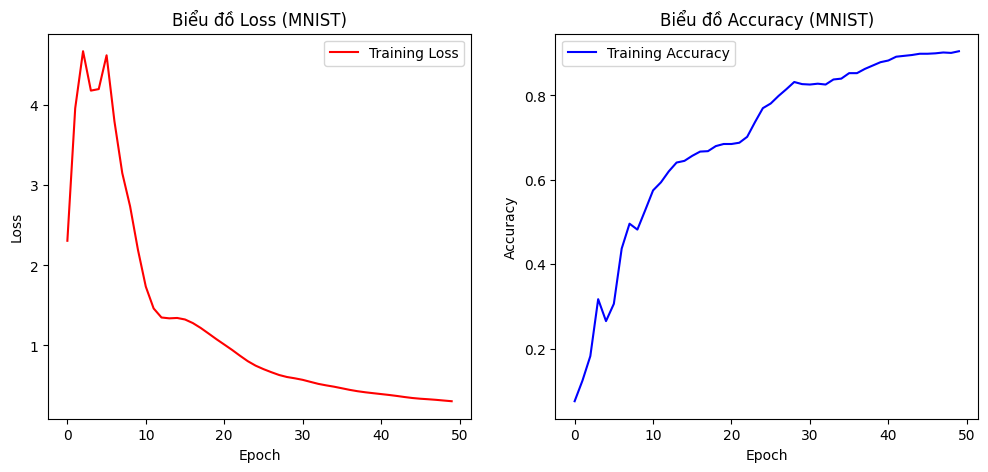

In [ ]:
plt.figure(figsize=(12, 5))

# Biểu đồ Loss
plt.subplot(1, 2, 1)
plt.plot(loss_history, color='red', label='Training Loss')
plt.title('Biểu đồ Loss (MNIST)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Biểu đồ Accuracy
plt.subplot(1, 2, 2)
plt.plot(acc_history, color='blue', label='Training Accuracy')
plt.title('Biểu đồ Accuracy (MNIST)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Tập cat and dog

In [89]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [90]:
# tạo dữ liệu từ tập cat and dog
transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])
train_dataset = datasets.ImageFolder("dog_cat/train", transform=transform)
test_dataset  = datasets.ImageFolder("dog_cat/test", transform=transform)
# lấy dữ liệu train
X_train = []
y_train = []
for img, label in train_dataset:
    X_train.append(img.numpy().flatten())
    y_train.append(label)
# lấy dữ liệu test
X_test = []
y_test = []
for img, label in test_dataset:
    X_test.append(img.numpy().flatten())
    y_test.append(label)
# chuyển sang numpy
X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)
# chuyển sang tensor
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train).unsqueeze(1)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test).unsqueeze(1)

In [108]:
#Xây ANN bằng PyTorch
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        self.layer1 = nn.Linear(64*64*3, 128)
        self.relu1 = nn.ReLU()
        self.layer2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.layer3 = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu1(x)
        x = self.layer2(x)
        x = self.relu2(x)
        x = self.layer3(x)
        x = self.sigmoid(x)
        return x
    
model = ANN()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# huấn luyển
epochs = 100
loss_history = []
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    if (epoch+1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], loss: {loss.item():.4f}")

Epoch [20/100], loss: 0.6889
Epoch [40/100], loss: 0.6739
Epoch [60/100], loss: 0.6576
Epoch [80/100], loss: 0.6431
Epoch [100/100], loss: 0.6272


In [109]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test)
    y_pred = (y_pred > 0.5).float()
    accuracy = (y_pred.eq(y_test).sum() / y_test.size(0)).item()
    print(f"Độ chính xác: {accuracy*100:.2f}%")

Độ chính xác: 61.54%


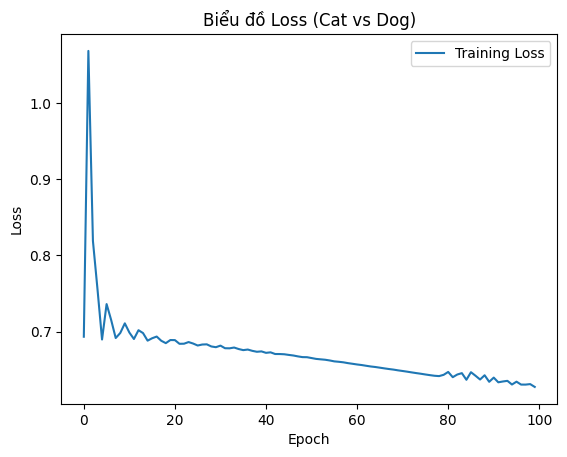

In [112]:
plt.plot(loss_history, label='Training Loss')
plt.title('Biểu đồ Loss (Cat vs Dog)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()